# Experiment: Will Adding Geometry Information Improve the Performance of TIC?
This notebook organizes the workflow to test whether incorporating geometry information into the TIC pipeline enhances pseudotime inference performance.

## Geometry Feature Mathematical Definitions

Below are the mathematical definitions for the geometry-based features extracted for each cell boundary polygon.

1. **Area**  
$$
A = \frac{1}{2} \left| \sum_{i=1}^{N} x_i y_{i+1} - y_i x_{i+1} \right|
$$

2. **Perimeter**  
$$
P = \sum_{i=1}^{N} \sqrt{ (x_{i+1} - x_i)^2 + (y_{i+1} - y_i)^2 }
$$

3. **Aspect Ratio**  
Let  
$$
w = \max(x) - \min(x), \quad h = \max(y) - \min(y)
$$  
Then  
$$
\mathrm{AspectRatio} = \frac{w}{h}
$$

4. **Compactness**  
$$
\mathrm{Compactness} = \frac{P^2}{A}
$$

5. **Centroid**  
$$
(\bar{x}, \bar{y}) = \left( \frac{1}{N} \sum_{i=1}^{N} x_i, \; \frac{1}{N} \sum_{i=1}^{N} y_i \right)
$$

The final geometry features vector for each cell is:
$$
\mathbf{f} = [A, P, \mathrm{AspectRatio}, \mathrm{Compactness}, \bar{x}, \bar{y}]
$$




## 1. Setup
Import required libraries and load the dataset. Make sure to set your OpenAI API key in `utils/config.py`.

In [1]:
from tic.data import load_xenium_dataset

# Load subset of Xenium FFPE human breast dataset with a mask
adata = load_xenium_dataset(
    dataset='xenium_ffpe_human_breast',
    n_cells=20000,
    include_mask=True
)
adata

/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset already exists in /Users/zhangjiahao/.cache/tic/xenium_ffpe_human_breast, skipping download.
[✓] Loaded xenium_ffpe_human_breast: 20000 cells × 541 genes.
[INFO] Loading cell boundaries from: cell_boundaries.parquet
[INFO] Loading nucleus boundaries from: nucleus_boundaries.parquet


AnnData object with n_obs × n_vars = 20000 × 541
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'tissue_id', 'data_level', 'cell_boundaries'
    obsm: 'spatial'

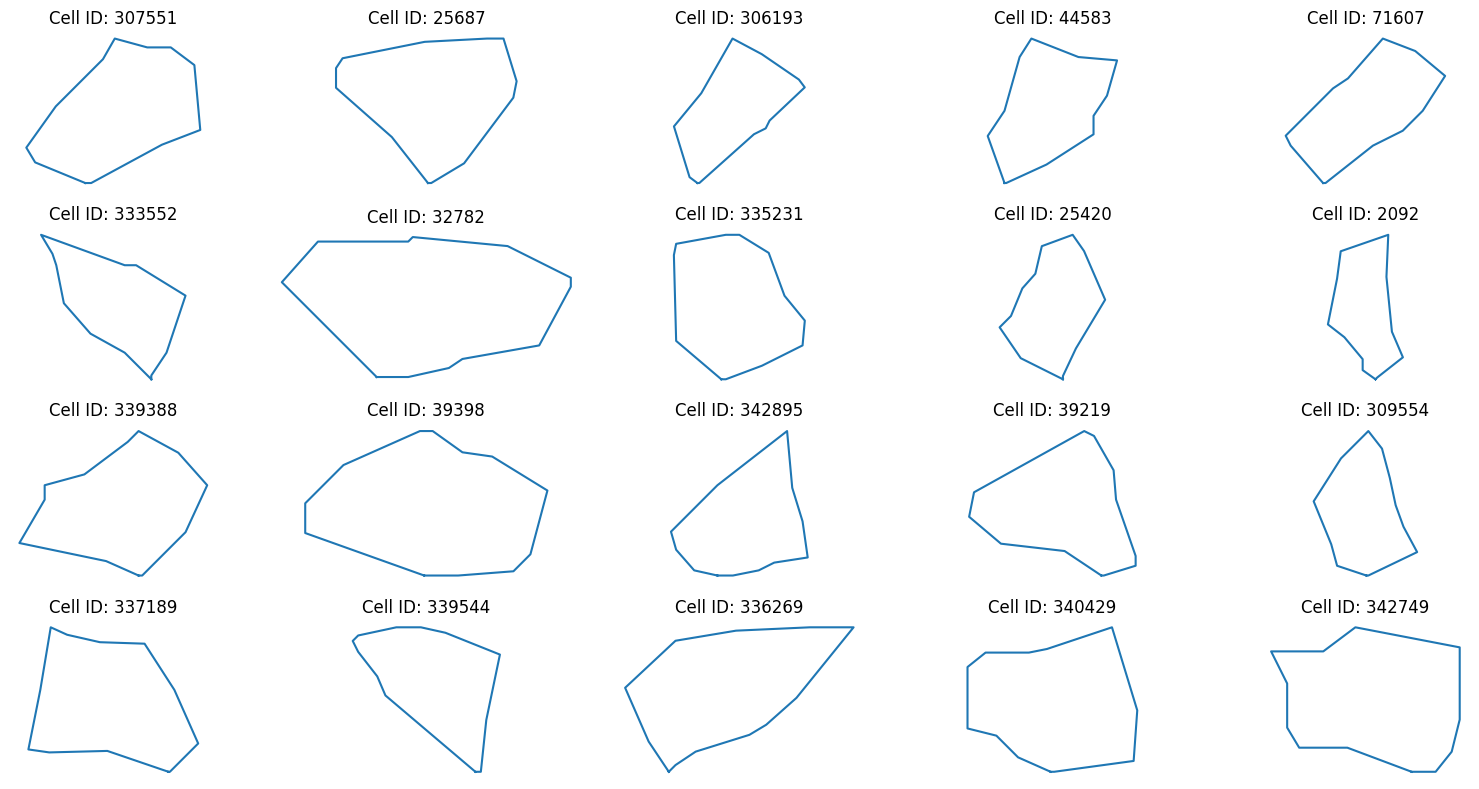

In [6]:
import matplotlib.pyplot as plt
from tic.plotting import plot_cell_boundary
import numpy as np

# random select 20 valid cells from adata.obs_names
cell_ids = np.random.choice(adata.obs_names, size=20, replace=False)

fig, axs = plt.subplots(4, 5, figsize=(16, 8))

for ax, cell_id in zip(axs.flatten(), cell_ids):
    try:
        plot_cell_boundary(adata, cell_id, ax=ax, show=False)
    except ValueError as e:
        ax.set_title(f"Cell {cell_id} (no boundary)")
        ax.axis("off")

plt.tight_layout()
plt.show()

### Dataset Description
Demonstration of gene expression profiling for FFPE human breast samples on the Xenium platform.
- Pre-designed Xenium Human Breast Gene Expression Panel (v1)
- Custom add-on panel of 100 genes
- Sample types: infiltrating ductal carcinoma, ductal carcinoma in situ, invasive lobular carcinoma
- Protocols: Xenium FFPE Tissue Preparation, Deparaffinization & Decrosslinking, H&E staining and registration.

In [2]:
print(adata.obs['cell_type'].unique)  # Inspect annotated cell types

<bound method Series.unique of 39686     unknown
39690     unknown
39684     unknown
39680     unknown
39685     unknown
           ...   
333517    unknown
42022     unknown
1220      unknown
70725     unknown
338045    unknown
Name: cell_type, Length: 20000, dtype: object>


## 2. Annotation Pipeline
Run clustering, marker gene extraction, and LLM-based annotation.

In [3]:
from tic.annotation import annotate_adata
from utils.config import API_KEY

DATASET_DESCRIPTION = '''
Demonstration of gene expression profiling for FFPE human breast samples on the Xenium platform. The dataset contains tumor cells; ensure at least one cluster is annotated as tumor.
'''

# Run the full annotation pipeline
adata_pred, cluster_annotation = annotate_adata(
    adata=adata,
    assign_params={
        'min_cells': 0,
        'min_genes': 0,
        'n_pca': 50,
        'n_neighbors': 15,
        'resolution': 2.0,
        'n_filter_highly_variable_genes': 2000,
    },
    llm_model_name='openai',
    llm_kwargs={'api_key': API_KEY, 'mirror': True},
    dataset_description=DATASET_DESCRIPTION,
    groupby='leiden',
    rank_genes_groups_method='t-test',
    n_genes=10,
    copy=True,
    return_cluster_annotation=True,
)

import json
print(json.dumps(cluster_annotation, indent=2))

/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:243: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:414: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(msg, UserWarning)
/Users/zhangjiahao/Test/TIC/tic/annotation/annotation.py:71: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=resolution)
... storing 'cell_type' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical
/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/scanpy/to

{
  "0": {
    "assigned_cell_type": "Mast cells",
    "reasoning": "TPSAB1 is a canonical marker for mast cells encoding tryptase, an enzyme abundantly expressed in mast cell granules. KLRD1 also appears (NK cell marker), but the strong presence of TPSAB1 dominates, and the rest are controls/blanks."
  },
  "1": {
    "assigned_cell_type": "Luminal epithelial/tumor cells",
    "reasoning": "Markers such as DSP, GATA3, TACSTD2, ANKRD30A, KRT23, and FOXA1 are highly characteristic of luminal epithelial cells and breast tumor cells. GATA3 and FOXA1 are master regulators for hormone-responsive breast cancer."
  },
  "2": {
    "assigned_cell_type": "Fibroblasts (Stromal cells)",
    "reasoning": "LUM, POSTN, MMP2, SFRP4, and PDGFRB denote activated fibroblasts/myofibroblasts; ACTA2 is also a myofibroblast marker. These genes are typical of tumor stroma."
  },
  "3": {
    "assigned_cell_type": "Myeloid cells / Macrophages",
    "reasoning": "LYZ, FCER1G, FGL2, CXCR4, CD68, AIF1, and FCGR3

## 3. Visualization of Annotation Results

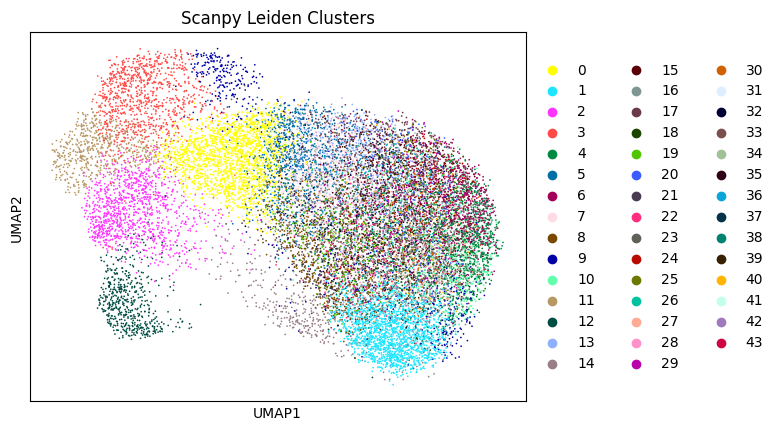

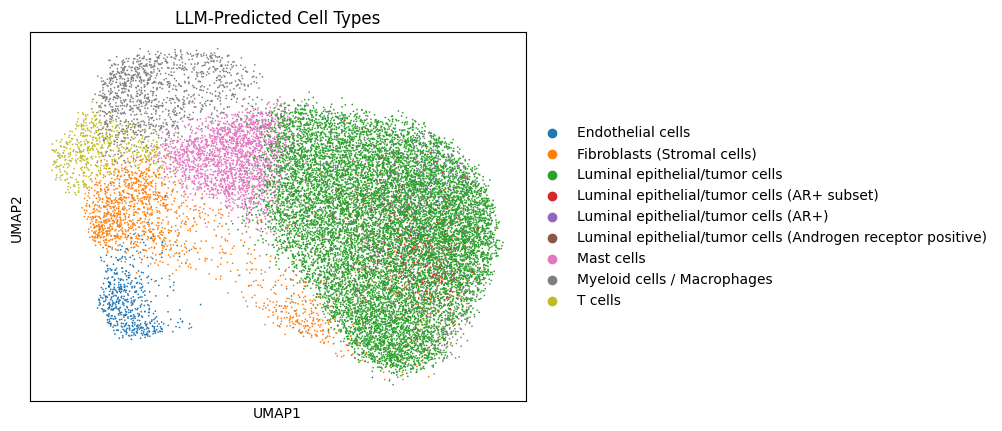

In [4]:
import scanpy as sc

# UMAP of Leiden clusters
sc.pl.umap(adata_pred, color=['leiden'], title='Scanpy Leiden Clusters')

# UMAP of LLM-predicted cell types
sc.pl.umap(adata_pred, color=['pred_cell_type'], title='LLM-Predicted Cell Types')

In [5]:
# Update original AnnData with predicted cell types
adata.obs['cell_type'] = adata_pred.obs['pred_cell_type']
print(adata.obs['cell_type'].unique())

# Count tumor cell populations
tumor_cell_types = []
for ct in adata.obs['cell_type'].unique():
    if 'tumor' in ct.lower():
        print(f"{ct}: {adata[adata.obs['cell_type'] == ct].n_obs} cells")
        tumor_cell_types.append(ct)
print(len(tumor_cell_types))
print(adata.obs['cell_type'].unique())

['Mast cells', 'Luminal epithelial/tumor cells', 'Myeloid cells / Macrophages', 'Luminal epithelial/tumor cells (AR+)', 'Fibroblasts (Stromal cells)', 'Luminal epithelial/tumor cells (AR+ subset)', 'T cells', 'Luminal epithelial/tumor cells (Androgen rece..., 'Endothelial cells']
Categories (9, object): ['Endothelial cells', 'Fibroblasts (Stromal cells)', 'Luminal epithelial/tumor cells', 'Luminal epithelial/tumor cells (AR+ subset)', ..., 'Luminal epithelial/tumor cells (Androgen rece..., 'Mast cells', 'Myeloid cells / Macrophages', 'T cells']
Luminal epithelial/tumor cells: 12842 cells
Luminal epithelial/tumor cells (AR+): 244 cells
Luminal epithelial/tumor cells (AR+ subset): 236 cells
Luminal epithelial/tumor cells (Androgen receptor positive): 384 cells
4
['Mast cells', 'Luminal epithelial/tumor cells', 'Myeloid cells / Macrophages', 'Luminal epithelial/tumor cells (AR+)', 'Fibroblasts (Stromal cells)', 'Luminal epithelial/tumor cells (AR+ subset)', 'T cells', 'Luminal epithelial/

## 4. Feature Extraction with Geometry Information
Extract features using both gene composition and spatial geometry.

In [6]:
from tic.wrappers import FeatureWrapper

fw = FeatureWrapper(
    recipe='tme_default',
    centre_types=tumor_cell_types[:1],
)
fw_adata = fw.fit(adata)
fw_adata

/Users/zhangjiahao/Test/TIC/tic/graph/pp/neighbors.py:100: SparseEfficiencyWarning: Taking maximum (minimum) with > 0 (< 0) number results to a dense matrix.
  adj = (mat + mat.T).maximum(1).tocsr()
/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 12842 × 541
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'feature_modes', 'graph_params', 'subgraph_params', 'X_predictors_names', 'X_predictors_meta'
    obsm: 'geometry_features', 'centre_gene', 'composition', 'neighbor_gene_sum', 'same_type_gene_sum', 'same_type_gene_average', 'celltype_gene_count', 'X_predictors'

In [7]:
import numpy as np

print('Geometry features shape:', fw_adata.obsm['geometry_features'].shape)
print('NaN fraction (geometry):', np.mean(np.isnan(fw_adata.obsm['geometry_features'])))
print('NaN fraction (composition):', np.mean(np.isnan(fw_adata.obsm['composition'])))

Geometry features shape: (12842, 6)
NaN fraction (geometry): 0.0001557389814670612
NaN fraction (composition): 0.0


### Cleaning NaN Entries
Remove cells with any NaN in geometry features and synchronize the AnnData.

In [8]:
valid = ~np.isnan(fw_adata.obsm['geometry_features']).any(axis=1)
fw_adata = fw_adata[valid].copy()
print('Remaining NaN fraction (geometry):', np.mean(np.isnan(fw_adata.obsm['geometry_features'])))

Remaining NaN fraction (geometry): 0.0


## 5. Creating Mixed Features
Concatenate geometry and gene composition features.

In [9]:
geometry = fw_adata.obsm['geometry_features']
gene_comp = fw_adata.obsm['composition']

fw_adata.obsm['mixed_features'] = np.concatenate([geometry, gene_comp], axis=1)
print('Mixed features shape:', fw_adata.obsm['mixed_features'].shape)

Mixed features shape: (12830, 15)


## 6. Pseudotime Analysis
Compare pseudotime inference using mixed vs. gene-only features.

2025-05-26 21:12:55,424 | INFO     | tic.pipeline.pseudotime | Pseudotime pipeline order: ['_ClusterStep', '_DRStep', '_PseudotimeStep', '_MetricStep']
/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/pyslingshot/util.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if isint(cluster_labels[0]):
/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/pyslingshot/util.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif isstr(cluster_labels[0]):
  0%|          | 0/10 [00:00<?, ?it/s]/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/pyslingshot/slingshot.py:333: RuntimeWarning: in

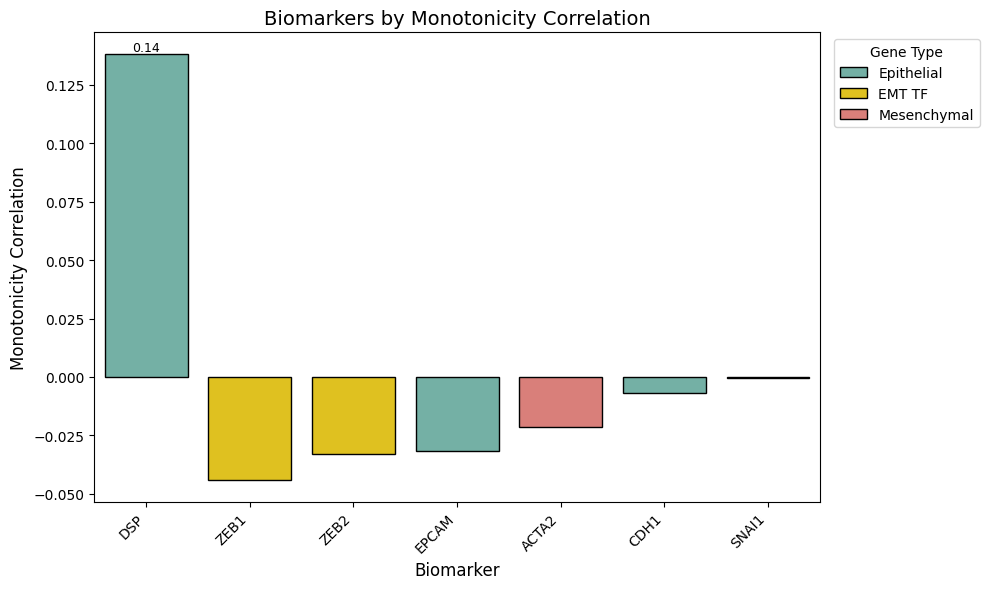

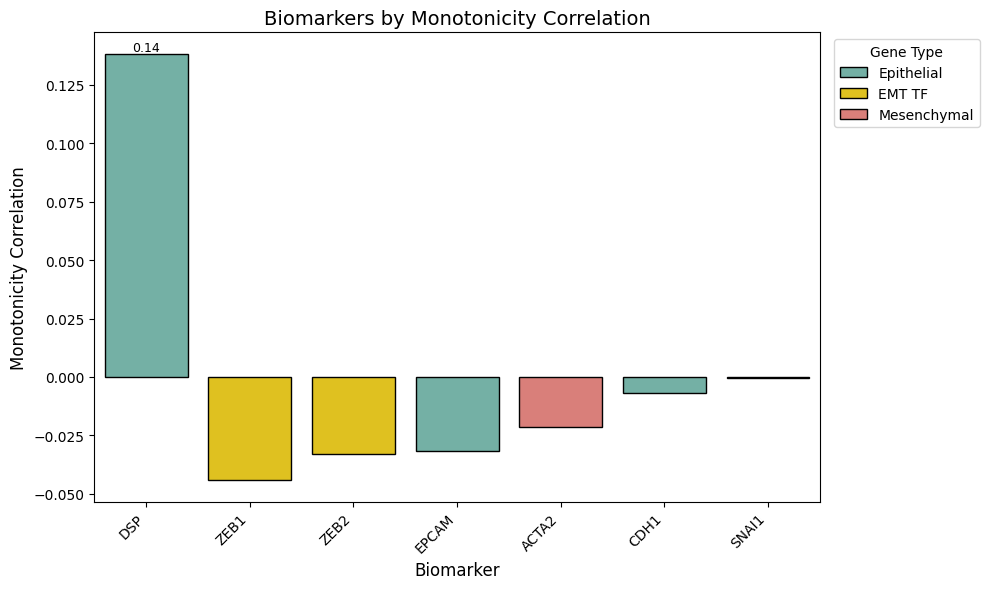

In [10]:
from tic.wrappers import PseudotimeWrapper
from tic.plotting import plot_monotonicity_metrics_bar

# Mixed features pseudotime
pw_mixed = PseudotimeWrapper(rep_key='mixed_features')
pw_mixed.fit(fw_adata)
plot_monotonicity_metrics_bar(metrics=pw_mixed.metrics)

2025-05-26 21:19:00,611 | INFO     | tic.pipeline.pseudotime | Pseudotime pipeline order: ['_ClusterStep', '_DRStep', '_PseudotimeStep', '_MetricStep']
/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/pyslingshot/util.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if isint(cluster_labels[0]):
/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/pyslingshot/util.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif isstr(cluster_labels[0]):
  0%|          | 0/10 [00:00<?, ?it/s]/opt/anaconda3/envs/tic_env_test/lib/python3.10/site-packages/pyslingshot/slingshot.py:333: RuntimeWarning: in

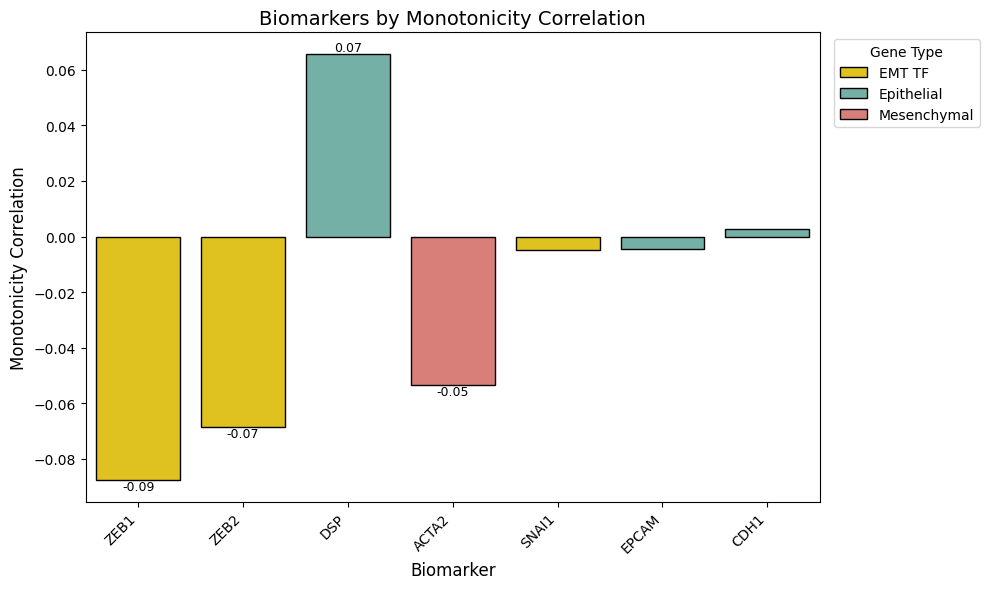

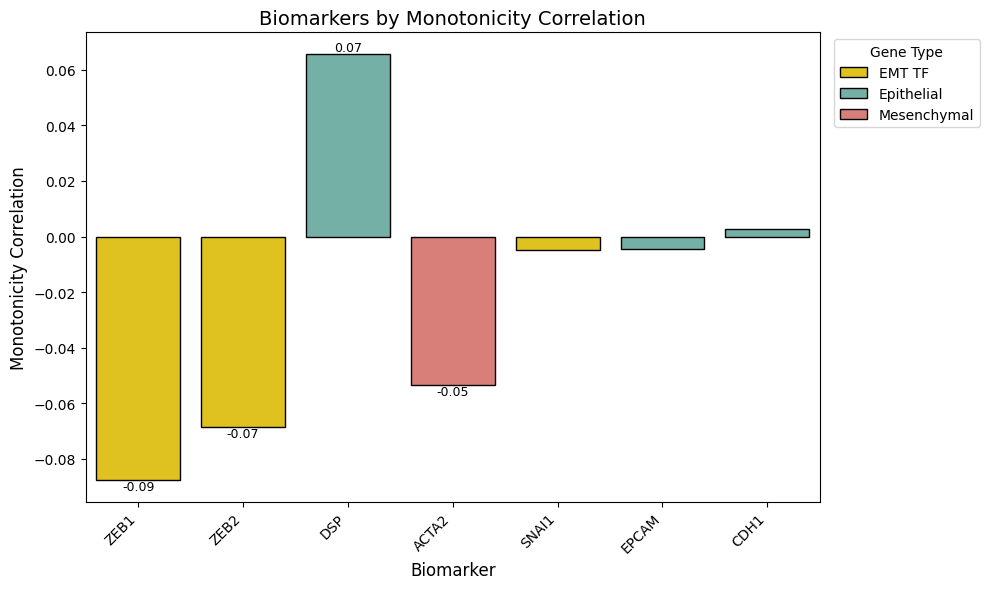

In [11]:
# composition-only features pseudotime
pw_gene = PseudotimeWrapper(rep_key='composition')
pw_gene.fit(fw_adata)
plot_monotonicity_metrics_bar(metrics=pw_gene.metrics)

## 7. Conclusion
Summarize findings: Does including geometry information improve the pseudotime metrics?